In [38]:
import torch
from TD3Agent.agent import TD3Agent
from Simulation.system_functions import PolymerCSTR
import numpy as np
import os
from utils.td3_helpers import load_and_prepare_system_data
from Simulation.mpc import MpcSolver, compute_observer_gain
from TD3Agent.reward_functions import make_reward_fn_mpc_quadratic, make_reward_fn_relative_QR
from utils.scaling_helpers import apply_min_max
from Plotting_fns.rl_plots import plot_rl_results_disturbance

## Initialize the system

In [39]:
# First initiate the system
# Parameters
Ad = 2.142e17           # h^-1
Ed = 14897              # K
Ap = 3.816e10           # L/(molh)
Ep = 3557               # K
At = 4.50e12            # L/(molh)
Et = 843                # K
fi = 0.6                # Coefficient
m_delta_H_r = -6.99e4   # j/mol
hA = 1.05e6             # j/(Kh)
rhocp = 1506            # j/(Kh)
rhoccpc = 4043          # j/(Kh)
Mm = 104.14             # g/mol
system_params = np.array([Ad, Ed, Ap, Ep, At, Et, fi, m_delta_H_r, hA, rhocp, rhoccpc, Mm])

In [40]:
# Design Parameters
CIf = 0.5888    # mol/L
CMf = 8.6981    # mol/L
Qi = 108.       # L/h
Qs = 459.       # L/h
Tf = 330.       # K
Tcf = 295.      # K
V = 3000.       # L
Vc = 3312.4     # L

system_design_params = np.array([CIf, CMf, Qi, Qs, Tf, Tcf, V, Vc])

In [41]:
# Steady State Inputs
Qm_ss = 378.    # L/h
Qc_ss = 471.6   # L/h

system_steady_state_inputs = np.array([Qc_ss, Qm_ss])

In [42]:
# Sampling time of the system
delta_t = 0.5 # 30 mins

In [43]:
# Initiate the CSTR for steady state values
cstr = PolymerCSTR(system_params, system_design_params, system_steady_state_inputs, delta_t)
steady_states={"ss_inputs":cstr.ss_inputs,
               "y_ss":cstr.y_ss}

## Loading the system matrices, min max scaling, and min max of the states

In [44]:
dir_path = os.path.join(os.getcwd(), "Data")

In [45]:
# Defining the range of setpoints for data generation
setpoint_y = np.array([[2.8, 320.],
                       [5., 326.]])
u_min = np.array([71.6, 78])
u_max = np.array([870, 670])

system_data = load_and_prepare_system_data(steady_states=steady_states, setpoint_y=setpoint_y, u_min=u_min, u_max=u_max)

In [46]:
A_aug = system_data["A_aug"]
B_aug = system_data["B_aug"]
C_aug = system_data["C_aug"]

In [47]:
data_min = system_data["data_min"]
data_max = system_data["data_max"]

In [48]:
min_max_states = {'max_s': np.array([256.79686253, 256.01560603,  48.99447186, 144.79949103,
          2.82199733,   3.14014989,   2.78866348,   3.71691422,
          6.2029936 ]),
                  'min_s': np.array([ -272.28060121, -1112.33972595,   -76.63993491,  -608.60327886,
           -3.94399122,    -3.93115257,    -2.9532091 ,    -4.06547624,
          -28.25906582])}

In [49]:
y_sp_scaled_deviation = system_data["y_sp_scaled_deviation"]

In [50]:
b_min = system_data["b_min"]
b_max = system_data["b_max"]

In [51]:
min_max_dict = system_data["min_max_dict"]
min_max_dict["x_max"] = np.array([256.79686253, 256.01560603,  48.99447186, 144.79949103,
          2.82199733,   3.14014989,   2.78866348,   3.71691422,
          6.2029936 ])
min_max_dict["x_min"] = np.array([ -272.28060121, -1112.33972595,   -76.63993491,  -608.60327886,
           -3.94399122,    -3.93115257,    -2.9532091 ,    -4.06547624,
          -28.25906582])

In [52]:
# Setpoints in deviation form
inputs_number = int(B_aug.shape[1])
y_sp_scenario = np.array([[4.5, 324],
                          [3.4, 321]])

y_sp_scenario = (apply_min_max(y_sp_scenario, data_min[inputs_number:], data_max[inputs_number:])
                 - apply_min_max(steady_states["y_ss"], data_min[inputs_number:], data_max[inputs_number:]))
n_tests = 200
set_points_len = 400
TEST_CYCLE = [False, False]
warm_start = 0
ACTOR_FREEZE = 0 * set_points_len
warm_start_plot = warm_start * 2 * set_points_len + ACTOR_FREEZE

In [53]:
# Observer Gain
poles = np.array(np.array([0.44619852, 0.33547649, 0.36380595, 0.70467118, 0.3562966,
                           0.42900673, 0.4228262 , 0.96916776, 0.91230187]))
L = compute_observer_gain(A_aug, C_aug, poles)

The system is observable.


C:\Users\HAMEDI\OneDrive - McMaster University\PythonProjects\Polymer_example\Simulation\mpc.py:114: UserWarning: Convergence was not reached after maxiter iterations.
You asked for a tolerance of 0.001, we got 0.9999999422182038.
  obs_gain_calc = signal.place_poles(A.T, C.T, desired_poles, method='KNV0')


## Setting The hyperparameters for the TD3 Agent

In [54]:
set_points_number = int(C_aug.shape[0])
inputs_number = int(B_aug.shape[1])
STATE_DIM = int(A_aug.shape[0]) + set_points_number + inputs_number
ACTION_DIM = int(B_aug.shape[1])
n_outputs = C_aug.shape[0]
ACTOR_LAYER_SIZES = [512, 512, 512, 512, 512]
CRITIC_LAYER_SIZES = [512, 512, 512, 512, 512]
BUFFER_CAPACITY = 40000
ACTOR_LR = 5e-5
CRITIC_LR = 5e-4
SMOOTHING_STD = 0.005
NOISE_CLIP = 0.01
# EXPLORATION_NOISE_STD = 0.01
GAMMA = 0.995
TAU = 0.005 # 0.01
MAX_ACTION = 1
POLICY_DELAY = 2
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
BATCH_SIZE = 256
STD_START = 0.02
STD_END = 0.001
STD_DECAY_RATE = 0.99992
STD_DECAY_MODE = "exp"

In [55]:
td3_agent = TD3Agent(
    state_dim=STATE_DIM,
    action_dim=ACTION_DIM,
    actor_hidden=ACTOR_LAYER_SIZES,
    critic_hidden=CRITIC_LAYER_SIZES,
    gamma=GAMMA,
    actor_lr=ACTOR_LR,
    critic_lr=CRITIC_LR,
    batch_size=BATCH_SIZE,
    policy_delay=POLICY_DELAY,
    target_policy_smoothing_noise_std=SMOOTHING_STD,
    noise_clip=NOISE_CLIP,
    max_action=MAX_ACTION,
    tau=TAU,
    std_start=STD_START,
    std_end=STD_END,
    std_decay_rate=STD_DECAY_RATE,
    std_decay_mode=STD_DECAY_MODE,
    buffer_size=BUFFER_CAPACITY,
    device=DEVICE,
    actor_freeze=ACTOR_FREEZE,
)

In [56]:
agent_path = r"C:\Users\HAMEDI\OneDrive - McMaster University\PythonProjects\Polymer_example\Data\models\agent_2507171027.pkl"
td3_agent.load(agent_path)

Agent loaded successfully from: C:\Users\HAMEDI\OneDrive - McMaster University\PythonProjects\Polymer_example\Data\models\agent_2507171027.pkl


# MPC Config.

In [57]:
# MPC parameters
n_inputs = 2
predict_h = 9
cont_h = 3
u_ss = apply_min_max(steady_states['ss_inputs'], data_min[:n_inputs], data_max[:n_inputs])
b_min = apply_min_max(np.array([71.6, 78]), data_min[:n_inputs], data_max[:n_inputs])
b_max= apply_min_max(np.array([870, 670]), data_min[:n_inputs], data_max[:n_inputs])
b1 = (b_min[0]-u_ss[0], b_max[0]-u_ss[0])
b2 = (b_min[1]-u_ss[1], b_max[1]-u_ss[1])
bnds = (b1, b2)*cont_h
cons = []
IC_opt = np.zeros(n_inputs*cont_h)
Q1_penalty = 5.
Q2_penalty = 1.
R1_penalty = 1
R2_penalty = 1

In [58]:
MPC_obj = MpcSolver(A_aug, B_aug, C_aug,
    Q_out=np.array([Q1_penalty, Q2_penalty]),
    R_in=np.array([R1_penalty, R2_penalty]),
    NP=predict_h,
    NC=cont_h)

## Reward configuration

In [59]:
n_inputs = 2

dy = data_max[n_inputs:] - data_min[n_inputs:]
y_sp_nom = 0.5 * (data_min[n_inputs:] + data_max[n_inputs:])

k_rel = np.array([0.003, 0.0003])
band_floor_phys = np.array([0.006, 0.07])

band_phys = np.maximum(k_rel * np.abs(y_sp_nom), band_floor_phys)

scale_factor = 1.0  # use 2.0 for [-1, 1] scaling, 1.0 for [0, 1]
band_scaled = scale_factor * band_phys / dy

q0 = 1.4
Q_diag = q0 / np.maximum(band_scaled ** 2, 1e-12)

print("dy:", dy)
print("y_sp_nom:", y_sp_nom)
print("band_phys:", band_phys)
print("band_scaled:", band_scaled)
print("Q_diag:", Q_diag)

dy: [0.22165278 0.78153727]
y_sp_nom: [  3.83915067 323.21371982]
band_phys: [0.01151745 0.09696412]
band_scaled: [0.05196169 0.12406845]
Q_diag: [518.51529284  90.95055189]


In [60]:
Q_diag = np.array([518., 90.])          # rounded from the band-based calculation
R_diag = np.array([90., 90.])          # move cost for du_scaled ~ 0.02

n_inputs = 2

print("Band scaled are:")

params, reward_fn = make_reward_fn_relative_QR(
    data_min, data_max, n_inputs,
    k_rel, band_floor_phys,
    Q_diag, R_diag,
    tau_frac=0.7,
    gamma_out=0.5, gamma_in=0.5,
    beta=7.0, gate="geom", lam_in=1.0,
    bonus_kind="exp", bonus_k=12.0, bonus_p=0.6, bonus_c=20.0,
)
print(params)

Band scaled are:
{'k_rel': array([0.003 , 0.0003]), 'band_floor_phys': array([0.006, 0.07 ]), 'band_floor_scaled': array([0.02706937, 0.08956707]), 'Q_diag': array([518.,  90.]), 'R_diag': array([90., 90.]), 'tau_frac': 0.7, 'gamma_out': 0.5, 'gamma_in': 0.5, 'beta': 7.0, 'gate': 'geom', 'lam_in': 1.0, 'bonus_kind': 'exp', 'bonus_k': 12.0, 'bonus_p': 0.6, 'bonus_c': 20.0}


In [61]:
params_qp, reward_fn_qp = make_reward_fn_mpc_quadratic(Q_diag=np.array([5., 1.]), R_diag=np.array([1., 1.]))
print(params_qp)

{'Q_diag': array([5., 1.]), 'R_diag': array([1., 1.])}


# Disturbance Profile

In [62]:
nominal_qs = 459
nominal_qi = 108
nominal_hA = 1.05e6
qi_change = 0.95
qs_change = 1.05
ha_change = 0.92

# Lyapunov Idea

In [63]:
import numpy as np

try:
    import cvxpy as cp

    HAS_CVXPY = True
except Exception:
    HAS_CVXPY = False


def _diag_psd_from_vector(diag_vals, size, eps=1e-12, default=1.0):
    """
    Build a diagonal positive semidefinite matrix from a vector.

    Parameters
    ----------
    diag_vals : array-like or None
        Diagonal entries. If None, default * I is returned.
    size : int
        Matrix size.
    eps : float, optional
        Minimum allowed diagonal value.
    default : float, optional
        Default diagonal value if diag_vals is None.

    Returns
    -------
    M : np.ndarray
        Diagonal PSD matrix of shape (size, size).
    v : np.ndarray
        Diagonal vector actually used.
    """
    if diag_vals is None:
        v = default * np.ones(size, dtype=float)
    else:
        v = np.asarray(diag_vals, float).reshape(-1)
        if v.size != size:
            raise ValueError(
                f"Diagonal size mismatch. Expected {size}, got {v.size}."
            )
        v = np.maximum(v, eps)

    return np.diag(v), v


def compute_ss_target_slack_bounded(
        A,
        B,
        C,
        y_sp,
        d_hat,
        u_min,
        u_max,
        u_nom=None,
        Qs_diag=None,
        Ru_diag=None,
        w_x=1e-6,
        solver_pref=("OSQP", "CLARABEL", "SCS"),
        return_debug=False,
):
    """
    Compute the bounded steady-state target for the offset-free model
    using a soft output-matching formulation with slack.

    Model
    -----
    x_{k+1} = A x_k + B u_k
    y_k = C x_k + d_k

    Steady-state target problem
    ---------------------------
    minimize over x_s, u_s, s:

        (u_s - u_nom)^T R_u (u_s - u_nom)
        + s^T Q_s s
        + w_x ||x_s||_2^2

    subject to

        (I - A) x_s - B u_s = 0
        C x_s - (y_sp - d_hat) = s
        u_min <= u_s <= u_max

    All variables are assumed to be in the same coordinates.
    In your implementation, that means scaled deviation coordinates.

    Parameters
    ----------
    A, B, C : np.ndarray
        State-space matrices of the physical linear model, not the full
        augmented matrices.
    y_sp : array-like
        Desired setpoint in output deviation coordinates.
    d_hat : array-like
        Estimated output disturbance in the same output deviation coordinates.
    u_min, u_max : array-like
        Input bounds in input deviation coordinates.
    u_nom : array-like or None, optional
        Nominal steady-state input in deviation coordinates.
        If None, zero is used. This is the correct default for your setup.
    Qs_diag : array-like or None, optional
        Output slack penalty diagonal.
    Ru_diag : array-like or None, optional
        Steady-state input penalty diagonal.
    w_x : float, optional
        Small state regularization weight.
    solver_pref : tuple of str, optional
        CVXPY solver preference order.
    return_debug : bool, optional
        If True, also return a debug dictionary.

    Returns
    -------
    x_s : np.ndarray
        Steady-state state target.
    u_s : np.ndarray
        Steady-state input target.
    d_s : np.ndarray
        Steady-state disturbance target, equal to d_hat here.
    dbg : dict, optional
        Diagnostics dictionary returned only if return_debug is True.

    Notes
    -----
    This function does not silently fall back to an unbounded problem.
    If the QP fails, success=False is returned in dbg and the returned
    x_s, u_s are set to None.
    """
    if not HAS_CVXPY:
        raise ImportError(
            "CVXPY is required for the bounded slack steady-state target solver."
        )

    A = np.asarray(A, float)
    B = np.asarray(B, float)
    C = np.asarray(C, float)

    y_sp = np.asarray(y_sp, float).reshape(-1)
    d_hat = np.asarray(d_hat, float).reshape(-1)
    u_min = np.asarray(u_min, float).reshape(-1)
    u_max = np.asarray(u_max, float).reshape(-1)

    n_x = A.shape[0]
    n_u = B.shape[1]
    n_y = C.shape[0]

    if A.shape != (n_x, n_x):
        raise ValueError("A must be square.")
    if B.shape[0] != n_x:
        raise ValueError("B row dimension must match A.")
    if C.shape[1] != n_x:
        raise ValueError("C column dimension must match A.")
    if y_sp.size != n_y:
        raise ValueError("y_sp size mismatch.")
    if d_hat.size != n_y:
        raise ValueError("d_hat size mismatch.")
    if u_min.size != n_u or u_max.size != n_u:
        raise ValueError("u_min/u_max size mismatch.")
    if np.any(u_min > u_max):
        raise ValueError("u_min must be <= u_max elementwise.")

    if u_nom is None:
        u_nom = np.zeros(n_u, dtype=float)
    else:
        u_nom = np.asarray(u_nom, float).reshape(-1)
        if u_nom.size != n_u:
            raise ValueError("u_nom size mismatch.")

    Qs, qs_used = _diag_psd_from_vector(Qs_diag, n_y, eps=1e-12, default=1.0)
    Ru, ru_used = _diag_psd_from_vector(Ru_diag, n_u, eps=1e-12, default=1.0)

    y_t = y_sp - d_hat

    x = cp.Variable(n_x)
    u = cp.Variable(n_u)
    s = cp.Variable(n_y)

    objective = (
            cp.quad_form(u - u_nom, Ru)
            + cp.quad_form(s, Qs)
            + float(w_x) * cp.sum_squares(x)
    )

    constraints = [
        (np.eye(n_x) - A) @ x - B @ u == 0.0,
        C @ x - y_t == s,
        u >= u_min,
        u <= u_max,
    ]

    problem = cp.Problem(cp.Minimize(objective), constraints)

    solved = False
    last_status = None
    last_solver = None
    last_err = None

    tol_dyn = 1e-8
    tol_slack = 1e-6

    for solver_name in solver_pref:
        try:
            x.value = None
            u.value = None
            s.value = None

            problem.solve(
                solver=solver_name,
                warm_start=False,
                verbose=False,
            )

            last_status = problem.status
            last_solver = solver_name

            if x.value is None or u.value is None or s.value is None:
                continue

            x_try = np.asarray(x.value).reshape(-1)
            u_try = np.asarray(u.value).reshape(-1)
            s_try = np.asarray(s.value).reshape(-1)

            r_dyn = (np.eye(n_x) - A) @ x_try - B @ u_try
            r_slack = C @ x_try - y_t - s_try

            r_dyn_inf = float(np.max(np.abs(r_dyn)))
            r_slack_inf = float(np.max(np.abs(r_slack)))

            if problem.status == "optimal":
                solved = True
                break

            if problem.status == "optimal_inaccurate":
                if r_dyn_inf <= tol_dyn and r_slack_inf <= tol_slack:
                    solved = True
                    break

        except Exception as ex:
            last_err = str(ex)
            last_status = None
            last_solver = solver_name

    if not solved:
        dbg = {
            "success": False,
            "solver": last_solver,
            "status": last_status,
            "err": last_err,
            "bounded": True,
            "y_target": y_sp.copy(),
            "y_shifted_target": y_t.copy(),
            "d_s": d_hat.copy(),
            "u_nom": u_nom.copy(),
            "Qs_diag": qs_used.copy(),
            "Ru_diag": ru_used.copy(),
        }
        if return_debug:
            return None, None, d_hat.copy(), dbg
        return None, None, d_hat.copy()

    x_s = np.asarray(x.value).reshape(-1)
    u_s = np.asarray(u.value).reshape(-1)
    s_val = np.asarray(s.value).reshape(-1)
    d_s = d_hat.copy()

    r_dyn = (np.eye(n_x) - A) @ x_s - B @ u_s
    r_y = C @ x_s - y_t
    y_s_pred = C @ x_s + d_s

    dbg = {
        "success": True,
        "solver": last_solver,
        "status": problem.status,
        "bounded": True,
        "objective_value": (
            float(problem.value) if problem.value is not None else None
        ),
        "r_dyn_inf": float(np.max(np.abs(r_dyn))),
        "r_y_inf": float(np.max(np.abs(r_y))),
        "slack_y_inf": float(np.max(np.abs(s_val))),
        "slack_y_norm": float(np.linalg.norm(s_val, ord=2)),
        "y_s_pred": y_s_pred,
        "y_target": y_sp.copy(),
        "y_shifted_target": y_t.copy(),
        "d_s": d_s.copy(),
        "u_nom": u_nom.copy(),
        "Qs_diag": qs_used.copy(),
        "Ru_diag": ru_used.copy(),
        "x_s_norm": float(np.linalg.norm(x_s, ord=2)),
        "u_s_norm": float(np.linalg.norm(u_s, ord=2)),
    }

    if return_debug:
        return x_s, u_s, d_s, dbg
    return x_s, u_s, d_s


def compute_ss_target_slack_from_augmented(
        A_aug,
        B_aug,
        C_aug,
        xhat_aug,
        y_sp,
        u_min,
        u_max,
        u_nom=None,
        Qs_diag=None,
        Ru_diag=None,
        w_x=1e-6,
        solver_pref=("OSQP", "CLARABEL", "SCS"),
        return_debug=False,
):
    """
    Convenience wrapper for your augmented offset-free observer state.

    This function extracts:
      - A, B, C from the augmented matrices
      - d_hat from xhat_aug

    and then calls compute_ss_target_slack_bounded().

    Your augmentation is assumed to be

        A_aug = [[A, 0],
                 [0, I]]

        B_aug = [[B],
                 [0]]

        C_aug = [C, I]

    so the physical state dimension is

        n_x = n_aug - n_y

    where n_y is the number of outputs.

    Parameters
    ----------
    A_aug, B_aug, C_aug : np.ndarray
        Augmented model matrices.
    xhat_aug : array-like
        Current augmented state estimate [x_hat; d_hat].
    y_sp : array-like
        Setpoint in scaled deviation output coordinates.
    u_min, u_max : array-like
        Input bounds in scaled deviation input coordinates.
    u_nom, Qs_diag, Ru_diag, w_x, solver_pref, return_debug :
        Same meaning as in compute_ss_target_slack_bounded().

    Returns
    -------
    x_s, u_s, d_s, dbg
        Same outputs as the core function.
    """
    A_aug = np.asarray(A_aug, float)
    B_aug = np.asarray(B_aug, float)
    C_aug = np.asarray(C_aug, float)
    xhat_aug = np.asarray(xhat_aug, float).reshape(-1)

    n_aug = A_aug.shape[0]
    n_y = C_aug.shape[0]
    n_x = n_aug - n_y

    if A_aug.shape[1] != n_aug:
        raise ValueError("A_aug must be square.")
    if B_aug.shape[0] != n_aug:
        raise ValueError("B_aug row dimension must match A_aug.")
    if C_aug.shape[1] != n_aug:
        raise ValueError("C_aug column dimension must match A_aug.")
    if xhat_aug.size != n_aug:
        raise ValueError("xhat_aug size mismatch.")

    A = A_aug[:n_x, :n_x]
    B = B_aug[:n_x, :]
    C = C_aug[:, :n_x]
    d_hat = xhat_aug[n_x:]

    return compute_ss_target_slack_bounded(
        A=A,
        B=B,
        C=C,
        y_sp=y_sp,
        d_hat=d_hat,
        u_min=u_min,
        u_max=u_max,
        u_nom=u_nom,
        Qs_diag=Qs_diag,
        Ru_diag=Ru_diag,
        w_x=w_x,
        solver_pref=solver_pref,
        return_debug=return_debug,
    )

In [64]:
from scipy.linalg import solve_discrete_are
import numpy as np


def design_riccati_P_aug_physical(
    A_aug,
    B_aug,
    C_aug,
    Qy_diag,
    Ru_diag=None,
    u_min=None,
    u_max=None,
    u_nom=None,
    lambda_u=1.0,
    pd_eps=0.0,
    eps_r=1e-9,
    return_debug=False,
):
    """
    Design an augmented Lyapunov matrix by solving a DARE on the physical
    subsystem only, then embedding the result into augmented coordinates.

    This is consistent with the offset-free augmentation

        A_aug = [[A, 0],
                 [0, I]]

        B_aug = [[B],
                 [0]]

        C_aug = [C, I]

    and with the steady-state target calculation where the disturbance target
    is set to the current estimate d_s = d_hat.

    Design model
    ------------
    Physical deviation dynamics:

        x_tilde(k+1) = A x_tilde(k) + B u_tilde(k)

    Stage cost:

        l(x_tilde, u_tilde) =
            x_tilde.T Qx x_tilde + u_tilde.T Ru u_tilde

    with

        Qx = C.T Qy C

    where Qy is the output-error penalty in the physical output coordinates.

    Parameters
    ----------
    A_aug, B_aug, C_aug : np.ndarray
        Augmented model matrices.
    Qy_diag : array-like
        Diagonal entries of Qy, the physical output penalty.
    Ru_diag : array-like or None, optional
        Diagonal entries of Ru. If None, Ru is built from a Bryson-style rule
        using distance from u_nom to the nearest bound.
    u_min, u_max : array-like or None, optional
        Input bounds in the same coordinates used for the controller.
        For your setup, these are scaled deviation bounds.
        Required if Ru_diag is None.
    u_nom : array-like or None, optional
        Nominal input about which the Riccati design is defined.
        For your scaled deviation coordinates, the correct default is zero.
    lambda_u : float, optional
        Scalar multiplier used only when Ru_diag is None.
    pd_eps : float, optional
        Disturbance-block regularization for the augmented P matrix.
        Default is 0.0, which is the clean mathematical choice.
        Use a tiny positive value only if needed for downstream numerics.
    eps_r : float, optional
        Minimum allowed diagonal entry for Ru.
    return_debug : bool, optional
        If True, also return a debug dictionary.

    Returns
    -------
    P_aug : np.ndarray
        Augmented Lyapunov matrix

            P_aug = [[Px, 0],
                     [0, Pd]]

        where Px is the physical Riccati solution and Pd = pd_eps * I.
    dbg : dict, optional
        Diagnostics dictionary returned only if return_debug is True.

    Notes
    -----
    1. This function does NOT solve a DARE on the full augmented system.
       It solves the DARE only on the physical subsystem.

    2. The returned matrix is a practical augmented Lyapunov matrix, not the
       exact value matrix of the full augmented offset-free model.

    3. The default u_nom = 0 is correct for scaled deviation coordinates.
    """
    A_aug = np.asarray(A_aug, float)
    B_aug = np.asarray(B_aug, float)
    C_aug = np.asarray(C_aug, float)
    Qy_diag = np.asarray(Qy_diag, float).reshape(-1)

    n_aug = A_aug.shape[0]
    n_u = B_aug.shape[1]
    n_y = C_aug.shape[0]
    n_x = n_aug - n_y

    if A_aug.shape[1] != n_aug:
        raise ValueError("A_aug must be square.")
    if B_aug.shape[0] != n_aug:
        raise ValueError("B_aug row dimension must match A_aug.")
    if C_aug.shape[1] != n_aug:
        raise ValueError("C_aug column dimension must match A_aug.")
    if Qy_diag.size != n_y:
        raise ValueError(
            f"Qy_diag size mismatch. Expected {n_y}, got {Qy_diag.size}."
        )

    # Split the augmented model using the same convention as the
    # steady-state target selector.
    A = A_aug[:n_x, :n_x]
    B = B_aug[:n_x, :]
    C = C_aug[:, :n_x]

    # Default nominal input in scaled deviation coordinates is zero.
    if u_nom is None:
        u_nom = np.zeros(n_u, dtype=float)
    else:
        u_nom = np.asarray(u_nom, float).reshape(-1)
        if u_nom.size != n_u:
            raise ValueError(
                f"u_nom size mismatch. Expected {n_u}, got {u_nom.size}."
            )

    # Build Qy and the induced physical state penalty Qx = C.T Qy C.
    Qy = np.diag(np.maximum(Qy_diag, 0.0))
    Qx = C.T @ Qy @ C
    Qx = 0.5 * (Qx + Qx.T)

    # Build Ru.
    if Ru_diag is None:
        if u_min is None or u_max is None:
            raise ValueError(
                "u_min and u_max must be provided when Ru_diag is None."
            )

        u_min = np.asarray(u_min, float).reshape(-1)
        u_max = np.asarray(u_max, float).reshape(-1)

        if u_min.size != n_u or u_max.size != n_u:
            raise ValueError("u_min/u_max size mismatch.")
        if np.any(u_min > u_max):
            raise ValueError("u_min must be <= u_max elementwise.")
        if np.any(u_nom < u_min) or np.any(u_nom > u_max):
            raise ValueError(
                "u_nom must lie inside [u_min, u_max] for Bryson-style Ru."
            )

        # Correct allowable magnitude around the nominal point.
        # This is NOT half of the total interval unless u_nom is centered.
        u_allow = np.minimum(u_nom - u_min, u_max - u_nom)
        if np.any(u_allow <= 0.0):
            raise ValueError(
                "Each input must have positive room around u_nom."
            )

        Ru_diag = float(lambda_u) / np.maximum(u_allow ** 2, eps_r)

    Ru_diag = np.asarray(Ru_diag, float).reshape(-1)
    if Ru_diag.size != n_u:
        raise ValueError(
            f"Ru_diag size mismatch. Expected {n_u}, got {Ru_diag.size}."
        )

    Ru_diag = np.maximum(Ru_diag, eps_r)
    Ru = np.diag(Ru_diag)

    # Solve DARE on the physical subsystem only.
    Px = solve_discrete_are(A, B, Qx, Ru)
    Px = 0.5 * (Px + Px.T)

    # Embed into augmented coordinates.
    Pd = float(pd_eps) * np.eye(n_y, dtype=float)

    P_aug = np.block([
        [Px, np.zeros((n_x, n_y), dtype=float)],
        [np.zeros((n_y, n_x), dtype=float), Pd],
    ])
    P_aug = 0.5 * (P_aug + P_aug.T)

    if return_debug:
        dbg = {
            "n_x": n_x,
            "n_y": n_y,
            "n_u": n_u,
            "u_nom": u_nom.copy(),
            "Qy_diag": Qy_diag.copy(),
            "Qx": Qx.copy(),
            "Ru_diag": Ru_diag.copy(),
            "pd_eps": float(pd_eps),
        }
        return P_aug, dbg

    return P_aug

In [65]:
def lyap_V(x, P):
    """
    Compute the quadratic Lyapunov value V(x) = x.T P x.

    Parameters
    ----------
    x : array-like
        State vector.
    P : np.ndarray
        Symmetric positive semidefinite matrix.

    Returns
    -------
    float
        Quadratic value x.T P x.
    """
    x = np.asarray(x, float).reshape(-1, 1)
    P = np.asarray(P, float)
    return float((x.T @ P @ x).item())

In [66]:
def lyapunov_project_layer_augstate(
    xhat_aug,
    y_sp,
    u_rl_dev,
    u_prev_dev,
    u_min,
    u_max,
    A_aug,
    B_aug,
    C_aug,
    P_lyap,
    S_lyap,
    rho=0.99,
    eps_v=1e-9,
    w_rl=1.0,
    w_track=1.0,
    w_move=1.0,
    w_ss=1.0,
    Qy_track_diag=None,
    Rmove_diag=None,
    Qs_tgt_diag=None,
    Ru_tgt_diag=None,
    u_nom_tgt=None,
    w_x_tgt=1e-6,
    solver_pref_target=("OSQP", "CLARABEL", "SCS"),
    solver_pref_qp=("CLARABEL", "SCS", "ECOS"),
    tol=1e-10,
    box_tol=1e-9,
):
    """
    One-step Lyapunov projection layer in augmented coordinates.

    This function takes the RL-proposed input u_rl_dev and either:
      1. accepts it directly if it already satisfies the Lyapunov decrease
         condition, or
      2. solves a convex QP to find the closest acceptable input according to
         the chosen projection objective.

    The steady-state target is computed using the bounded slack target selector
    consistent with the offset-free augmented model.

    Parameters
    ----------
    xhat_aug : array-like
        Current augmented state estimate [x_hat; d_hat].
    y_sp : array-like
        Current setpoint in scaled deviation output coordinates.
    u_rl_dev : array-like
        RL-proposed input in scaled deviation input coordinates.
    u_prev_dev : array-like
        Previously applied input in scaled deviation coordinates.
    u_min, u_max : array-like
        Input bounds in scaled deviation coordinates.
    A_aug, B_aug, C_aug : np.ndarray
        Augmented offset-free model matrices.
    P_lyap : np.ndarray
        Augmented Lyapunov matrix.
    S_lyap : np.ndarray
        Matrix such that P_lyap ~= S_lyap.T @ S_lyap.
    rho : float, optional
        Lyapunov contraction factor. Must satisfy 0 < rho < 1.
    eps_v : float, optional
        Nonnegative Lyapunov slack constant in the decrease condition.
    w_rl, w_track, w_move, w_ss : float, optional
        Objective weights for RL closeness, tracking, move suppression, and
        steady-state-input closeness, respectively.
    Qy_track_diag : array-like or None, optional
        Diagonal weights for the one-step output tracking term.
    Rmove_diag : array-like or None, optional
        Diagonal weights for the move suppression term.
    Qs_tgt_diag : array-like or None, optional
        Diagonal output slack penalty used in the steady-state target selector.
    Ru_tgt_diag : array-like or None, optional
        Diagonal steady-state input penalty used in the target selector.
    u_nom_tgt : array-like or None, optional
        Nominal steady-state input for the target selector. In your scaled
        deviation coordinates, the correct default is zero.
    w_x_tgt : float, optional
        Small state regularization weight for the target selector.
    solver_pref_target : tuple of str, optional
        Solver preference order for the target selector QP.
    solver_pref_qp : tuple of str, optional
        Solver preference order for the projection QP.
    tol : float, optional
        Numerical tolerance for Lyapunov constraint checks.

    Returns
    -------
    u_out : np.ndarray
        Applied safe input in scaled deviation coordinates.
    info : dict
        Diagnostics and status information.

    Notes
    -----
    The Lyapunov guarantee holds only when:
      - the steady-state target selector succeeds, and
      - the projection QP is feasible or the RL action is directly accepted.

    If either optimization fails, this function returns the clipped RL input
    and reports the failure in `info`.
    """
    if not HAS_CVXPY:
        u_rl = np.asarray(u_rl_dev, float).reshape(-1)
        u_min = np.asarray(u_min, float).reshape(-1)
        u_max = np.asarray(u_max, float).reshape(-1)
        u_rl = np.clip(u_rl, u_min, u_max)
        return u_rl, {
            "used": False,
            "filtered": False,
            "method": "no_cvxpy",
            "success": False,
        }

    xhat_aug = np.asarray(xhat_aug, float).reshape(-1)
    y_sp = np.asarray(y_sp, float).reshape(-1)

    u_min = np.asarray(u_min, float).reshape(-1)
    u_max = np.asarray(u_max, float).reshape(-1)
    u_rl = np.asarray(u_rl_dev, float).reshape(-1)
    u_prev_dev = np.asarray(u_prev_dev, float).reshape(-1)

    A_aug = np.asarray(A_aug, float)
    B_aug = np.asarray(B_aug, float)
    C_aug = np.asarray(C_aug, float)
    P_lyap = np.asarray(P_lyap, float)
    S_lyap = np.asarray(S_lyap, float)

    if not (0.0 < float(rho) < 1.0):
        raise ValueError("rho must satisfy 0 < rho < 1.")
    if float(eps_v) < 0.0:
        raise ValueError("eps_v must be >= 0.")

    n_a = A_aug.shape[0]
    n_u = B_aug.shape[1]
    n_y = C_aug.shape[0]

    if A_aug.shape != (n_a, n_a):
        raise ValueError("A_aug must be square.")
    if B_aug.shape[0] != n_a:
        raise ValueError("B_aug row dimension must match A_aug.")
    if C_aug.shape[1] != n_a:
        raise ValueError("C_aug column dimension must match A_aug.")
    if P_lyap.shape != (n_a, n_a):
        raise ValueError("P_lyap shape mismatch.")
    if S_lyap.shape != (n_a, n_a):
        raise ValueError("S_lyap shape mismatch.")
    if xhat_aug.size != n_a:
        raise ValueError("xhat_aug size mismatch.")
    if y_sp.size != n_y:
        raise ValueError("y_sp size mismatch.")
    if u_min.size != n_u or u_max.size != n_u:
        raise ValueError("u_min/u_max size mismatch.")
    if u_rl.size != n_u:
        raise ValueError("u_rl_dev size mismatch.")
    if u_prev_dev.size != n_u:
        raise ValueError("u_prev_dev size mismatch.")
    if np.any(u_min > u_max):
        raise ValueError("u_min must be <= u_max elementwise.")

    # Clip RL proposal to the admissible input box.
    u_rl = np.clip(u_rl, u_min, u_max)

    def _diag_sqrt(diag_vals, size, default=1.0, eps=1e-12):
        if diag_vals is None:
            v = default * np.ones(size, dtype=float)
        else:
            v = np.asarray(diag_vals, float).reshape(-1)
            if v.size != size:
                raise ValueError(
                    f"Diagonal size mismatch. Expected {size}, got {v.size}."
                )
            v = np.maximum(v, eps)
        return np.sqrt(v), v

    qy_sqrt, qy_track_used = _diag_sqrt(Qy_track_diag, n_y, default=1.0)
    rmove_sqrt, rmove_used = _diag_sqrt(Rmove_diag, n_u, default=1.0)

    # ------------------------------------------------------------------
    # Step 1: compute the bounded slack steady-state target
    # ------------------------------------------------------------------
    x_s, u_s, d_s, dbg_tgt = compute_ss_target_slack_from_augmented(
        A_aug=A_aug,
        B_aug=B_aug,
        C_aug=C_aug,
        xhat_aug=xhat_aug,
        y_sp=y_sp,
        u_min=u_min,
        u_max=u_max,
        u_nom=u_nom_tgt,
        Qs_diag=Qs_tgt_diag,
        Ru_diag=Ru_tgt_diag,
        w_x=w_x_tgt,
        solver_pref=solver_pref_target,
        return_debug=True,
    )

    if not dbg_tgt.get("success", False) or x_s is None or u_s is None:
        return u_rl, {
            "used": False,
            "filtered": False,
            "success": False,
            "method": "target_fail",
            "target_dbg": dbg_tgt,
        }

    x_s_aug = np.concatenate([x_s, d_s], axis=0)
    x_tilde = xhat_aug - x_s_aug

    # ------------------------------------------------------------------
    # Step 2: build the one-step Lyapunov threshold
    # ------------------------------------------------------------------
    V_k = lyap_V(x_tilde, P_lyap)
    c = float(rho) * V_k + float(eps_v)

    # Predicted next deviation:
    # x_tilde_next(u) = A_aug x_tilde - B_aug u_s + B_aug u
    b_k = A_aug @ x_tilde - B_aug @ u_s

    # Predicted next output:
    # y_{k+1|k}(u) = C_aug (A_aug xhat_aug + B_aug u) = y0 + M u
    y0_k = C_aug @ (A_aug @ xhat_aug)
    M = C_aug @ B_aug

    # ------------------------------------------------------------------
    # Step 3: quick accept check for the RL action
    # ------------------------------------------------------------------
    x_tilde_next_rl = b_k + B_aug @ u_rl
    V_next_rl = float(np.sum((S_lyap @ x_tilde_next_rl) ** 2))

    y_pred_next_rl = y0_k + M @ u_rl
    e_pred_next_rl = y_pred_next_rl - y_sp
    track_inf_rl = float(np.max(np.abs(e_pred_next_rl)))

    base_info = {
        "used": True,
        "target_dbg": dbg_tgt,
        "rho": float(rho),
        "eps_v": float(eps_v),
        "V_k": V_k,
        "c": c,
        "u_rl": u_rl.copy(),
        "u_prev_dev": u_prev_dev.copy(),
        "u_s": u_s.copy(),
        "Qy_track_diag": qy_track_used.copy(),
        "Rmove_diag": rmove_used.copy(),
        "margin_rl": float(V_next_rl - c),
    }

    if V_next_rl <= c + tol:
        return u_rl, {
            **base_info,
            "success": True,
            "filtered": False,
            "method": "accept",
            "V_next": V_next_rl,
            "track_inf": track_inf_rl,
            "du_inf": 0.0,
        }

    # ------------------------------------------------------------------
    # Step 4: solve the one-step projection QP
    # ------------------------------------------------------------------
    u = cp.Variable(n_u)

    x_tilde_next = b_k + B_aug @ u
    y_pred_next = y0_k + M @ u
    e_pred_next = y_pred_next - y_sp

    objective = 0.0
    objective += float(w_rl) * cp.sum_squares(u - u_rl)
    objective += float(w_move) * cp.sum_squares(
        cp.multiply(rmove_sqrt, u - u_prev_dev)
    )
    objective += float(w_track) * cp.sum_squares(
        cp.multiply(qy_sqrt, e_pred_next)
    )
    objective += float(w_ss) * cp.sum_squares(u - u_s)

    constraints = [
        u >= u_min,
        u <= u_max,
        cp.sum_squares(S_lyap @ x_tilde_next) <= c,
    ]

    problem = cp.Problem(cp.Minimize(objective), constraints)

    solved = False
    last_status = None
    last_solver = None
    last_err = None
    last_box_violation = None
    last_margin_try = None

    for solver_name in solver_pref_qp:
        try:
            u.value = None

            problem.solve(
                solver=solver_name,
                warm_start=True,
                verbose=False,
            )

            last_status = problem.status
            last_solver = solver_name

            if u.value is None or problem.status is None:
                continue

            u_try = np.asarray(u.value).reshape(-1)
            x_tilde_next_try = b_k + B_aug @ u_try
            V_next_try = float(np.sum((S_lyap @ x_tilde_next_try) ** 2))
            margin_try = float(V_next_try - c)

            lower_violation = float(np.max(u_min - u_try))
            upper_violation = float(np.max(u_try - u_max))
            box_violation = max(lower_violation, upper_violation, 0.0)

            last_margin_try = margin_try
            last_box_violation = box_violation

            # Be strict: only accept truly optimal solutions
            if problem.status != "optimal":
                continue

            if margin_try > 10.0 * tol:
                continue

            if box_violation > box_tol:
                continue

            solved = True
            break

        except Exception as ex:
            last_err = str(ex)
            last_status = None
            last_solver = solver_name

    if not solved:
        return u_rl, {
            **base_info,
            "success": False,
            "filtered": False,
            "method": "qp_fail",
            "status": last_status,
            "solver": last_solver,
            "err": last_err,
            "V_next": V_next_rl,
            "track_inf": track_inf_rl,
            "qp_margin_try": last_margin_try,
            "qp_box_violation": last_box_violation,
        }

    u_star = np.asarray(u.value).reshape(-1)

    x_tilde_next_star = b_k + B_aug @ u_star
    V_next_star = float(np.sum((S_lyap @ x_tilde_next_star) ** 2))
    margin_star = float(V_next_star - c)

    lower_violation_star = float(np.max(u_min - u_star))
    upper_violation_star = float(np.max(u_star - u_max))
    box_violation_star = max(lower_violation_star, upper_violation_star, 0.0)

    if margin_star > 10.0 * tol or box_violation_star > box_tol:
        return u_rl, {
            **base_info,
            "success": False,
            "filtered": False,
            "method": "qp_fail",
            "status": problem.status,
            "solver": last_solver,
            "err": "accepted_qp_solution_failed_postcheck",
            "V_next": V_next_rl,
            "track_inf": track_inf_rl,
            "qp_margin_try": margin_star,
            "qp_box_violation": box_violation_star,
        }

    y_pred_next_star = y0_k + M @ u_star
    e_pred_next_star = y_pred_next_star - y_sp
    track_inf_star = float(np.max(np.abs(e_pred_next_star)))

    du_inf = float(np.max(np.abs(u_star - u_rl)))
    filtered = bool(du_inf > 1e-10)

    return u_star, {
        **base_info,
        "success": True,
        "filtered": filtered,
        "method": "qp",
        "status": problem.status,
        "solver": last_solver,
        "objective_value": (
            float(problem.value) if problem.value is not None else None
        ),
        "V_next": V_next_star,
        "margin_star": margin_star,
        "box_violation_star": box_violation_star,
        "track_inf": track_inf_star,
        "du_inf": du_inf,
    }

In [67]:
def factor_psd_left(P, neg_tol=1e-10):
    """
    Compute a left factor S of a symmetric PSD matrix P such that

        P = S.T @ S

    while preserving exact zero eigenvalues.

    Parameters
    ----------
    P : np.ndarray
        Symmetric positive semidefinite matrix.
    neg_tol : float, optional
        Tolerance for tiny negative eigenvalues caused by numerical noise.

    Returns
    -------
    S : np.ndarray
        Left factor satisfying S.T @ S = P up to numerical precision.

    Notes
    -----
    - Tiny negative eigenvalues in [-neg_tol, 0] are clipped to zero.
    - If a more negative eigenvalue is detected, an error is raised.
    """
    P = np.asarray(P, float)
    P = 0.5 * (P + P.T)

    w, Q = np.linalg.eigh(P)

    if np.min(w) < -neg_tol:
        raise ValueError(
            f"P is not positive semidefinite. Min eigenvalue = {np.min(w):.3e}"
        )

    w = np.where(w > 0.0, w, 0.0)
    S = np.diag(np.sqrt(w)) @ Q.T
    return S

In [68]:
def map_to_bounds(a, low, high):
    """ Map a in [-1, 1] to [low, high], elementwise.
    """
    a = np.asarray(a, float).reshape(-1)
    low = np.asarray(low, float).reshape(-1)
    high = np.asarray(high, float).reshape(-1)
    return low + 0.5 * (a + 1.0) * (high - low)

def inv_map_from_bounds(u, low, high, eps=1e-12):
    """
    Inverse map_to_bounds, clipped to [-1, 1].
    """
    u = np.asarray(u, float).reshape(-1)
    low = np.asarray(low, float).reshape(-1)
    high = np.asarray(high, float).reshape(-1)
    denom = np.maximum(high - low, eps)
    a = 2.0 * (u - low) / denom - 1.0
    return np.clip(a, -1.0, 1.0)

In [69]:
from utils.scaling_helpers import apply_rl_scaled, reverse_min_max, apply_min_max
from utils.helpers import generate_setpoints_training_rl_gradually


def run_rl_train(
    system,
    y_sp_scenario,
    n_tests,
    set_points_len,
    steady_states,
    min_max_dict,
    agent,
    MPC_obj,
    L,
    data_min,
    data_max,
    warm_start,
    test_cycle,
    nominal_qi,
    nominal_qs,
    nominal_ha,
    qi_change,
    qs_change,
    ha_change,
    reward_fn,
    mode="disturb",
    P_lyap=None,
    rho_lyap=0.99,
    lyap_eps=1e-9,
    lyap_tol=1e-10,
    w_rl=1.0,
    w_track=1.0,
    w_move=1.0,
    w_ss=1.0,
    Qy_track_diag=None,
    Rmove_diag=None,
    Qs_tgt_diag=None,
    Ru_tgt_diag=None,
    u_nom_tgt=None,
    w_x_tgt=1e-6,
    lambda_u_ric=1.0,
    pd_eps_ric=0.0,
    seed=0,
    use_lyap=False
):
    """
    RL training loop with a Lyapunov projection layer.

    Coordinate conventions
    ----------------------
    - u_prev_dev, u_rl_dev, u_dev_safe are in scaled deviation coordinates.
    - y_sp is in scaled deviation coordinates.
    - xhat_aug_store is the augmented estimator state compatible with
      MPC_obj.A, MPC_obj.B, MPC_obj.C.

    The projection layer enforces
    -----------------------------
    - input bounds
    - one-step Lyapunov decrease with respect to the augmented linear model

    The projection objective balances
    ---------------------------------
    - closeness to RL action
    - move suppression relative to previous input
    - one-step predicted tracking
    - closeness to the steady-state target input
    """
    (
        y_sp,
        nFE,
        sub_changes,
        time_in_sub_episodes,
        test_train_dict,
        WARM_START,
        qi,
        qs,
        ha,
    ) = generate_setpoints_training_rl_gradually(
        y_sp_scenario,
        n_tests,
        set_points_len,
        warm_start,
        test_cycle,
        nominal_qi,
        nominal_qs,
        nominal_ha,
        qi_change,
        qs_change,
        ha_change,
    )

    n_u = MPC_obj.B.shape[1]
    n_y = MPC_obj.C.shape[0]
    n_a = MPC_obj.A.shape[0]

    ss_scaled_u = apply_min_max(
        steady_states["ss_inputs"], data_min[:n_u], data_max[:n_u]
    )
    ss_scaled_y = apply_min_max(
        steady_states["y_ss"], data_min[n_u:], data_max[n_u:]
    )

    u_min = np.asarray(min_max_dict["u_min"], float).reshape(-1)
    u_max = np.asarray(min_max_dict["u_max"], float).reshape(-1)

    if Qy_track_diag is None:
        Qy_track_diag = np.asarray(MPC_obj.Q_out, float).reshape(-1)
    else:
        Qy_track_diag = np.asarray(Qy_track_diag, float).reshape(-1)

    if Rmove_diag is None:
        Rmove_diag = np.asarray(MPC_obj.R_in, float).reshape(-1)
    else:
        Rmove_diag = np.asarray(Rmove_diag, float).reshape(-1)

    if Qs_tgt_diag is None:
        Qs_tgt_diag = np.asarray(MPC_obj.Q_out, float).reshape(-1)
    else:
        Qs_tgt_diag = np.asarray(Qs_tgt_diag, float).reshape(-1)

    if Ru_tgt_diag is not None:
        Ru_tgt_diag = np.asarray(Ru_tgt_diag, float).reshape(-1)

    if P_lyap is None:
        P_lyap, _ = design_riccati_P_aug_physical(
            A_aug=MPC_obj.A,
            B_aug=MPC_obj.B,
            C_aug=MPC_obj.C,
            Qy_diag=Qy_track_diag,
            Ru_diag=None,
            u_min=u_min,
            u_max=u_max,
            u_nom=None,
            lambda_u=lambda_u_ric,
            pd_eps=pd_eps_ric,
            return_debug=True,
        )

    else:
        P_lyap = np.asarray(P_lyap, float)
        P_lyap = 0.5 * (P_lyap + P_lyap.T)

    S_lyap = factor_psd_left(P_lyap)

    if P_lyap.shape != (n_a, n_a):
        raise ValueError(
            f"P_lyap shape {P_lyap.shape} does not match augmented state {n_a}."
        )

    y_system = np.zeros((nFE + 1, n_y), dtype=float)
    y_system[0, :] = system.current_output

    u_scaled_applied = np.zeros((nFE, n_u), dtype=float)
    u_safe_dev_store = np.zeros((nFE, n_u), dtype=float)

    yhat = np.zeros((n_y, nFE), dtype=float)
    xhat_aug_store = np.zeros((n_a, nFE + 1), dtype=float)

    e_store = np.zeros((nFE + 1, n_y), dtype=float)
    rewards = np.zeros(nFE, dtype=float)
    avg_rewards = []
    lyap_info_storage = []

    total_checked = 0
    total_filtered = 0
    checked_in_block = 0
    filtered_in_block = 0

    test = False

    for k in range(nFE):
        if k in test_train_dict:
            test = bool(test_train_dict[k])

        u_prev_scaled = apply_min_max(
            system.current_input, data_min[:n_u], data_max[:n_u]
        )
        u_prev_dev = u_prev_scaled - ss_scaled_u

        y_meas_dev = (
            apply_min_max(system.current_output, data_min[n_u:], data_max[n_u:])
            - ss_scaled_y
        )

        y_hat_k = MPC_obj.C @ xhat_aug_store[:, k]
        yhat[:, k] = y_hat_k

        y_sp_k = np.asarray(y_sp[k, :], float).reshape(-1)
        e_k = y_meas_dev - y_sp_k
        e_store[k, :] = e_k

        rl_state = apply_rl_scaled(
            min_max_dict, xhat_aug_store[:, k], y_sp_k, u_prev_dev
        )

        if test:
            a = agent.act_eval(rl_state)
        else:
            a = agent.take_action(rl_state, explore=(not test))

        a = np.asarray(a, float).reshape(-1)
        a = np.clip(a, -1.0, 1.0)

        u_rl_dev = map_to_bounds(a, u_min, u_max)
        u_rl_dev = np.clip(u_rl_dev, u_min, u_max)

        if (k + 1) < y_sp.shape[0]:
            y_sp_kp1 = np.asarray(y_sp[k + 1, :], float).reshape(-1)
        else:
            y_sp_kp1 = y_sp_k.copy()

        if use_lyap:
            u_dev_safe, info = lyapunov_project_layer_augstate(
                xhat_aug=xhat_aug_store[:, k],
                y_sp=y_sp_k,
                u_rl_dev=u_rl_dev,
                u_prev_dev=u_prev_dev,
                u_min=u_min,
                u_max=u_max,
                A_aug=MPC_obj.A,
                B_aug=MPC_obj.B,
                C_aug=MPC_obj.C,
                P_lyap=P_lyap,
                S_lyap=S_lyap,
                rho=rho_lyap,
                eps_v=lyap_eps,
                w_rl=w_rl,
                w_track=w_track,
                w_move=w_move,
                w_ss=w_ss,
                Qy_track_diag=Qy_track_diag,
                Rmove_diag=Rmove_diag,
                Qs_tgt_diag=Qs_tgt_diag,
                Ru_tgt_diag=Ru_tgt_diag,
                u_nom_tgt=u_nom_tgt,
                w_x_tgt=w_x_tgt,
                solver_pref_target=("OSQP", "CLARABEL", "SCS"),
                solver_pref_qp=("CLARABEL", "SCS", "ECOS"),
                tol=lyap_tol,
                box_tol=1e-9,
            )

        else:
            u_dev_safe = u_rl_dev
            info = {"used": False, "method": "bypass", "success": True}

        lyap_info_storage.append(info)

        if info.get("used", False):
            total_checked += 1
            checked_in_block += 1
            if info.get("filtered", False):
                total_filtered += 1
                filtered_in_block += 1

        u_safe_dev_store[k, :] = u_dev_safe

        # Store the action that was actually applied, not the raw RL proposal.
        a_used = inv_map_from_bounds(u_dev_safe, u_min, u_max).astype(np.float32)

        u_scaled_applied[k, :] = u_dev_safe + ss_scaled_u
        u_plant = reverse_min_max(
            u_scaled_applied[k, :], data_min[:n_u], data_max[:n_u]
        )

        delta_u = u_scaled_applied[k, :] - u_prev_scaled

        # Apply disturbances before the plant step so they affect this step.
        if mode == "disturb":
            system.hA = ha[k]
            system.Qs = qs[k]
            system.Qi = qi[k]

        system.current_input = u_plant
        system.step()

        y_system[k + 1, :] = system.current_output

        y_next_dev = (
            apply_min_max(y_system[k + 1, :], data_min[n_u:], data_max[n_u:])
            - ss_scaled_y
        )
        e_next = y_next_dev - y_sp_kp1
        e_store[k + 1, :] = e_next

        innov = y_meas_dev - y_hat_k
        xhat_aug_store[:, k + 1] = (
            (MPC_obj.A @ xhat_aug_store[:, k])
            + (MPC_obj.B @ u_dev_safe)
            + (L @ innov)
        )

        delta_y = y_next_dev - y_sp_k
        y_sp_phys = reverse_min_max(
            y_sp_k + ss_scaled_y, data_min[n_u:], data_max[n_u:]
        )
        r = reward_fn(delta_y, delta_u, y_sp_phys)
        rewards[k] = float(r)

        next_u_dev = u_scaled_applied[k, :] - ss_scaled_u
        next_state = apply_rl_scaled(
            min_max_dict, xhat_aug_store[:, k + 1], y_sp_kp1, next_u_dev
        )

        done = 0.0

        if not test:
            agent.push(rl_state, a_used, float(r), next_state, float(done))
            if k >= WARM_START:
                _ = agent.train_step(actor_update=True)

        if k in sub_changes:
            start = max(0, k - time_in_sub_episodes + 1)
            avg_rewards.append(float(np.mean(rewards[start:k + 1])))
            print("Sub_Episode:", sub_changes[k], "| avg. reward:", avg_rewards[-1])

            block_ratio = (
                filtered_in_block / checked_in_block
                if checked_in_block > 0 else 0.0
            )
            total_ratio = (
                total_filtered / total_checked
                if total_checked > 0 else 0.0
            )

            print(
                "Lyap filtered in block:",
                filtered_in_block, "/", checked_in_block,
                "(ratio:", block_ratio, ")",
                "| total:",
                total_filtered, "/", total_checked,
                "(ratio:", total_ratio, ")"
            )

            last = lyap_info_storage[-1]
            last_tgt = last.get("target_dbg", {})

            print(
                "Last Lyap method:", last.get("method"),
                "| success:", last.get("success"),
                "| V_next:", last.get("V_next"),
                "| c:", last.get("c"),
                "| du_inf:", last.get("du_inf"),
                "| target_status:", last_tgt.get("status"),
                "| target_r_dyn_inf:", last_tgt.get("r_dyn_inf"),
                "| target_r_y_inf:", last_tgt.get("r_y_inf"),
                "| target_slack_inf:", last_tgt.get("slack_y_inf"),
            )

            filtered_in_block = 0
            checked_in_block = 0

    u_applied_phys = reverse_min_max(u_scaled_applied, data_min[:n_u], data_max[:n_u])

    return (
        y_system,
        u_applied_phys,
        avg_rewards,
        rewards,
        xhat_aug_store,
        nFE,
        time_in_sub_episodes,
        y_sp,
        yhat,
        e_store,
        qi,
        qs,
        ha,
        lyap_info_storage,
        u_safe_dev_store,
    )

In [70]:
cstr = PolymerCSTR(
    system_params, system_design_params, system_steady_state_inputs, delta_t
)

results = run_rl_train(
    cstr,
    y_sp_scenario,
    n_tests,
    set_points_len,
    steady_states,
    min_max_dict,
    td3_agent,
    MPC_obj,
    L,
    data_min,
    data_max,
    warm_start,
    TEST_CYCLE,
    nominal_qi,
    nominal_qs,
    nominal_hA,
    qi_change,
    qs_change,
    ha_change,
    reward_fn_qp,
    mode="disturb",
    P_lyap=None,
    rho_lyap=0.98,
    lyap_eps=1e-9,
    lyap_tol=1e-10,
    w_rl=1.0,
    w_track=1.0,
    w_move=0.2,
    w_ss=0.1,
    Qy_track_diag=None,
    Rmove_diag=None,
    Qs_tgt_diag=1e8 * np.asarray(MPC_obj.Q_out, float),
    Ru_tgt_diag=1.0 * np.ones(MPC_obj.B.shape[1]),
    u_nom_tgt=None,
    w_x_tgt=1e-6,
    lambda_u_ric=1.0,
    pd_eps_ric=0.0,
    seed=0,
    use_lyap=True,
)

(
    y_system,
    u_applied_phys,
    avg_rewards,
    rewards,
    xhatdhat,
    nFE,
    time_in_sub_episodes,
    y_sp,
    yhat,
    e_store,
    qi,
    qs,
    ha,
    lyap_info_storage,
    u_safe_dev_store,
) = results

Sub_Episode: 1 | avg. reward: -42.91217821168173
Lyap filtered in block: 26 / 800 (ratio: 0.0325 ) | total: 26 / 800 (ratio: 0.0325 )
Last Lyap method: accept | success: True | V_next: 41.62745820535962 | c: 46.90836617442945 | du_inf: 0.0 | target_status: optimal | target_r_dyn_inf: 1.5646800384863657e-08 | target_r_y_inf: 2.93149301533829 | target_slack_inf: 2.9314930155659993
Sub_Episode: 2 | avg. reward: -2186.3909736650567
Lyap filtered in block: 8 / 800 (ratio: 0.01 ) | total: 34 / 1600 (ratio: 0.02125 )
Last Lyap method: accept | success: True | V_next: 6.261625878582148 | c: 6.6230655661515945 | du_inf: 0.0 | target_status: optimal | target_r_dyn_inf: 1.8001766388837936e-07 | target_r_y_inf: 8.334866830093713 | target_slack_inf: 8.334867010111367
Sub_Episode: 3 | avg. reward: -450.08395366842245
Lyap filtered in block: 52 / 800 (ratio: 0.065 ) | total: 86 / 2400 (ratio: 0.035833333333333335 )
Last Lyap method: accept | success: True | V_next: 16.67584865877439 | c: 24.722221516

In [36]:
import os
import pickle


def save_lyap_debug_artifacts(
    lyap_info_storage,
    out_dir="Result",
    prefix="lyap_debug",
):
    """
    Save the raw Lyapunov/debug info list as a pickle file.

    This preserves the full nested structure of each step's info dict,
    including target solver diagnostics and any future-added fields.
    """
    os.makedirs(out_dir, exist_ok=True)

    pkl_path = os.path.join(out_dir, f"{prefix}_info.pkl")

    with open(pkl_path, "wb") as f:
        pickle.dump(lyap_info_storage, f)

    print("Saved:")
    print(pkl_path)

    return pkl_path

import pickle


def load_lyap_debug_artifacts(pkl_path):
    """
    Load the raw Lyapunov/debug info list from a pickle file.
    """
    with open(pkl_path, "rb") as f:
        lyap_info_storage = pickle.load(f)
    return lyap_info_storage

# Example usage:
pkl_path = save_lyap_debug_artifacts(
    lyap_info_storage,
    out_dir="Result",
    prefix="polymer_lyap",
)

Saved:
Result\polymer_lyap_info.pkl


In [37]:
out_dir = plot_rl_results_disturbance(
    y_sp, steady_states, nFE, delta_t, time_in_sub_episodes,
    y_system, u_applied_phys, avg_rewards, data_min, data_max, warm_start_plot,
    directory=dir_path, prefix_name="polymer_nominal",
    agent=td3_agent, delta_y_storage=e_store, rewards=rewards,
    dist={"qi": qi, "qs": qs, "ha": ha}
)

Top methods: [('proj_slack_qp', 159014), ('accept', 986)]
Top reasons: [('normal', 159401), ('sp_jump_relax', 599)]
n: 160000
used: 160000
filtered: 143555
slack_used: 157562
intervened: 158302
unsafe_attempt (V_next > c): 116774
solver_fail: 0
slack_v percentiles: {50: 0.01759956892344164, 90: 0.28587157122345164, 95: 0.7439118288638398, 99: 1.8749634149413001, 99.5: 2.702130204432181, 99.9: 8.195926275066446}
slack_rl percentiles: {50: 3.0899333615804866e-05, 90: 0.0033513175563571196, 95: 0.017513261309361764, 99: 0.06692035049954169, 99.5: 0.11827155818140339, 99.9: 0.47746926918479693}
du_inf percentiles: {50: 0.19961727180102007, 90: 0.20294208186619844, 95: 0.21711604664483927, 99: 0.2664703378245849, 99.5: 0.31791711126032646, 99.9: 0.6760451913362687}
lyap_gap percentiles: {50: 0.019293833931701865, 90: 0.4112965427256767, 95: 0.9019652376941898, 99: 16.77128677669344, 99.5: 37.74158418349751, 99.9: 43.51199851254376}
track_inf percentiles: {50: 0.18001715765237855, 90: 0.7563

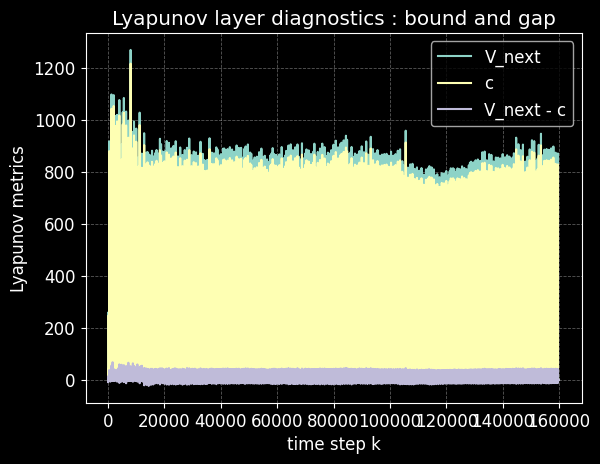

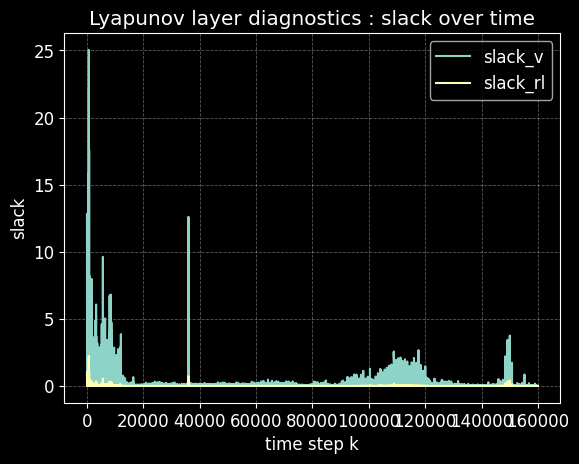

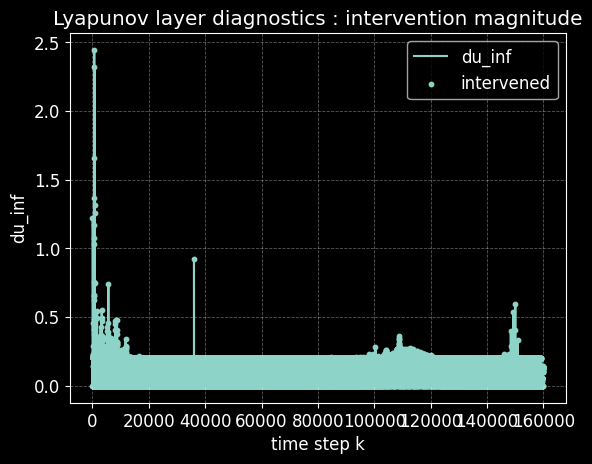

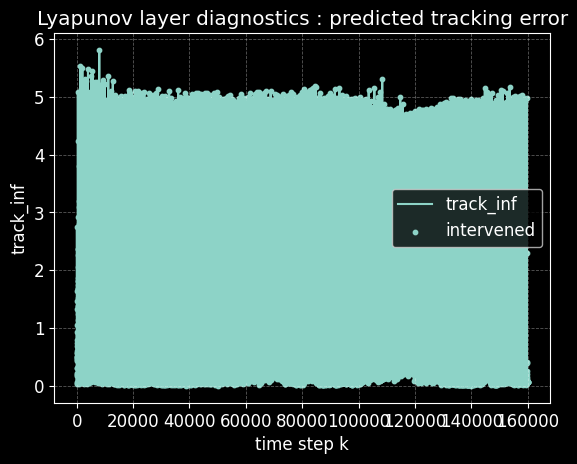

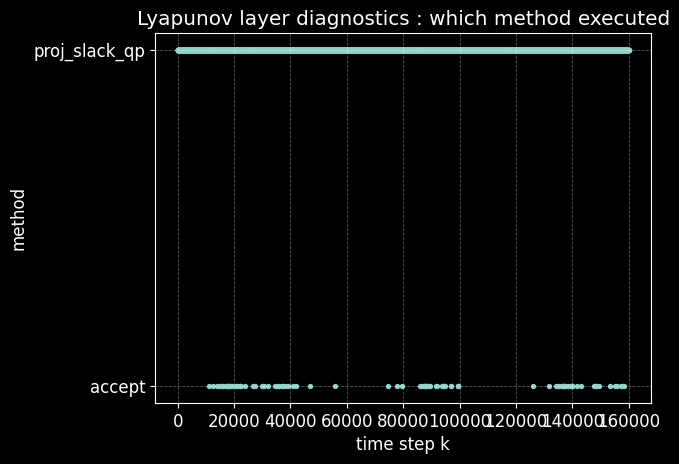

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

def _sf(x, default=0.0):
    try:
        if x is None:
            return default
        return float(x)
    except Exception:
        return default

def _sb(x, default=False):
    try:
        return bool(x)
    except Exception:
        return default

def _get_arr(storage, key, default=0.0):
    return np.array([_sf(d.get(key, default), default) for d in storage], dtype=float)

def _get_str(storage, key, default="none"):
    out = []
    for d in storage:
        v = d.get(key, default)
        out.append(default if v is None else str(v))
    return np.array(out, dtype=object)

def _percentiles(x, ps=(50, 90, 95, 99, 99.5, 99.9)):
    x = np.asarray(x, float)
    x = x[np.isfinite(x)]
    if x.size == 0:
        return {p: np.nan for p in ps}
    return {p: float(np.percentile(x, p)) for p in ps}

def make_lyap_df(lyap_info_storage, slack_thr=1e-9, du_thr=1e-10):
    n = len(lyap_info_storage)
    if n == 0:
        raise ValueError("lyap_info_storage is empty")

    method = _get_str(lyap_info_storage, "method", default="none")
    reason = _get_str(lyap_info_storage, "reason", default="none")

    used = np.array([_sb(d.get("used", False)) for d in lyap_info_storage], dtype=bool)
    filtered = np.array([_sb(d.get("filtered", False)) for d in lyap_info_storage], dtype=bool)

    V_k = _get_arr(lyap_info_storage, "V_k", default=np.nan)
    V_next = _get_arr(lyap_info_storage, "V_next", default=np.nan)
    c = _get_arr(lyap_info_storage, "c", default=np.nan)

    rho_eff = _get_arr(lyap_info_storage, "rho_eff", default=np.nan)
    eps_eff = _get_arr(lyap_info_storage, "eps_eff", default=np.nan)

    slack_v = _get_arr(lyap_info_storage, "slack_v", default=0.0)
    slack_rl = _get_arr(lyap_info_storage, "slack_rl", default=0.0)

    du_inf = _get_arr(lyap_info_storage, "du_inf", default=0.0)

    # Optional, only present if you log it in info dict
    track_inf = _get_arr(lyap_info_storage, "track_inf", default=np.nan)

    # Derived quantities
    lyap_gap = V_next - c
    denom = np.maximum(np.abs(c), 1e-12)
    lyap_gap_rel = lyap_gap / denom

    slack_used = (slack_v > slack_thr) | (slack_rl > slack_thr)
    intervened = used & (filtered | slack_used | (np.abs(du_inf) > du_thr))

    df = pd.DataFrame({
        "k": np.arange(n, dtype=int),
        "used": used,
        "filtered": filtered,
        "intervened": intervened,
        "method": method,
        "reason": reason,
        "V_k": V_k,
        "V_next": V_next,
        "c": c,
        "lyap_gap": lyap_gap,
        "lyap_gap_rel": lyap_gap_rel,
        "rho_eff": rho_eff,
        "eps_eff": eps_eff,
        "slack_v": slack_v,
        "slack_rl": slack_rl,
        "du_inf": du_inf,
        "track_inf": track_inf,
    })
    return df

def summarize_lyap(df, topk=12):
    methods = Counter(df["method"])
    reasons = Counter(df["reason"])

    slack_used = (df["slack_v"] > 1e-9) | (df["slack_rl"] > 1e-9)
    unsafe_attempt = df["used"] & np.isfinite(df["lyap_gap"]) & (df["lyap_gap"] > 0)
    solver_fail = df["method"].isin(["solver_fail", "no_cvxpy"])

    print("Top methods:", methods.most_common(topk))
    print("Top reasons:", reasons.most_common(topk))
    print("n:", int(len(df)))
    print("used:", int(df["used"].sum()))
    print("filtered:", int(df["filtered"].sum()))
    print("slack_used:", int(slack_used.sum()))
    print("intervened:", int(df["intervened"].sum()))
    print("unsafe_attempt (V_next > c):", int(unsafe_attempt.sum()))
    print("solver_fail:", int(solver_fail.sum()))
    print("slack_v percentiles:", _percentiles(df["slack_v"].to_numpy()))
    print("slack_rl percentiles:", _percentiles(df["slack_rl"].to_numpy()))
    print("du_inf percentiles:", _percentiles(df["du_inf"].to_numpy()))
    print("lyap_gap percentiles:", _percentiles(df["lyap_gap"].to_numpy()))

    if np.isfinite(df["track_inf"]).any():
        print("track_inf percentiles:", _percentiles(df["track_inf"].to_numpy()))

    print()
    print("Method x Reason crosstab (truncated):")
    cross = pd.crosstab(df["method"], df["reason"])
    with pd.option_context("display.max_rows", 12, "display.max_columns", 12):
        print(cross)

def show_worst_cases(df, k=15):
    cols = ["k", "method", "reason", "V_k", "V_next", "c", "lyap_gap", "slack_v", "slack_rl", "du_inf", "track_inf"]

    print()
    print("Worst by lyap_gap (largest attempted violation):")
    print(df.sort_values("lyap_gap", ascending=False).head(k)[cols])

    print()
    print("Worst by slack_v:")
    print(df.sort_values("slack_v", ascending=False).head(k)[cols])

    print()
    print("Worst by du_inf:")
    print(df.sort_values("du_inf", ascending=False).head(k)[cols])

def plot_lyap(df, downsample=10, title="Lyapunov layer diagnostics"):
    idx = np.arange(len(df), dtype=int)
    if downsample is not None and downsample > 1:
        idx = idx[::downsample]
    d = df.iloc[idx].copy()

    plt.figure()
    plt.plot(d["k"], d["V_next"], label="V_next")
    plt.plot(d["k"], d["c"], label="c")
    plt.plot(d["k"], d["lyap_gap"], label="V_next - c")
    plt.xlabel("time step k")
    plt.ylabel("Lyapunov metrics")
    plt.title(title + " : bound and gap")
    plt.legend()
    plt.grid(True)

    plt.figure()
    plt.plot(d["k"], d["slack_v"], label="slack_v")
    plt.plot(d["k"], d["slack_rl"], label="slack_rl")
    plt.xlabel("time step k")
    plt.ylabel("slack")
    plt.title(title + " : slack over time")
    plt.legend()
    plt.grid(True)

    plt.figure()
    plt.plot(d["k"], d["du_inf"], label="du_inf")
    k_int = d.loc[d["intervened"], "k"].to_numpy()
    du_int = d.loc[d["intervened"], "du_inf"].to_numpy()
    plt.scatter(k_int, du_int, label="intervened", s=10)
    plt.xlabel("time step k")
    plt.ylabel("du_inf")
    plt.title(title + " : intervention magnitude")
    plt.legend()
    plt.grid(True)

    if np.isfinite(df["track_inf"]).any():
        plt.figure()
        plt.plot(d["k"], d["track_inf"], label="track_inf")
        tr_int = d.loc[d["intervened"], "track_inf"].to_numpy()
        plt.scatter(k_int, tr_int, label="intervened", s=10)
        plt.xlabel("time step k")
        plt.ylabel("track_inf")
        plt.title(title + " : predicted tracking error")
        plt.legend()
        plt.grid(True)

    # Method timeline
    methods = sorted(df["method"].unique().tolist())
    m2i = {m: i for i, m in enumerate(methods)}
    y = np.array([m2i[m] for m in d["method"].to_numpy()], dtype=int)

    plt.figure()
    plt.scatter(d["k"], y, s=8)
    plt.yticks(range(len(methods)), methods)
    plt.xlabel("time step k")
    plt.ylabel("method")
    plt.title(title + " : which method executed")
    plt.grid(True)

    plt.show()

# ---- Run this after your experiment ----
df_lyap = make_lyap_df(lyap_info_storage)
summarize_lyap(df_lyap)
show_worst_cases(df_lyap, k=15)
plot_lyap(df_lyap, downsample=10)

# Optional: interactive table in Jupyter
try:
    from caas_jupyter_tools import display_dataframe_to_user
    display_dataframe_to_user("Lyapunov diagnostics per step", df_lyap)
except Exception:
    pass
